# Alertreck — Model Report

End-to-end ML report for the Alertreck anti-poaching audio system:

1. **Class distribution** of the processed feature shards
2. **Performance of all five models** across four ML paradigms
3. **Grad-CAM explainability** for the deployed CNN

Run top-to-bottom. Requires the repo's processed shards (`data/processed/`), the saved model
results (`models/*/results.json`), and the CNN checkpoint (`models/custom_cnn/best_model.pt`).

> 📦 **Data, dataset & models** (raw audio, processed shards, trained models) are on Google Drive: [Alertreck Data, Dataset & Models](https://drive.google.com/drive/folders/1U9BwIUNQ8Snl5RxR8LHthWfdOc_EdcTM?usp=sharing). Download `data/processed/` and `models/` into the repo root before running this notebook.


In [1]:
import json, sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether run from repo/ or repo/notebooks/
REPO = Path.cwd()
if not (REPO / "models").exists():
    REPO = REPO.parent
print("Repo:", REPO)

CLASSES = ["background_animals","background_wind_rain","threat_chainsaw",
           "threat_dog","threat_gunshot","threat_human","threat_vehicle"]
SHORT = {c: c.replace("background_","bg_").replace("threat_","") for c in CLASSES}
# Some result files use short class names (W2V2) — normalise back to full names
NAME_MAP = {v:k for k,v in SHORT.items()}
def norm(k): return NAME_MAP.get(k, k)

COLORS = ["#4CAF50","#4CAF50","#F44336","#F44336","#F44336","#F44336","#F44336"]  # green=bg, red=threat
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":0.3})


Repo: /Users/cococe/Desktop/CAPSTONE FILES/alertreck


## 1. Class Distribution of the Shards

The processed log-mel shards (`data/processed/mel/`), counted per class across the clean
train / val / test splits. Background classes in green, threat classes in red.


In [2]:
def count_split(split):
    d = REPO / "data/processed/mel" / split
    c = Counter()
    for s in sorted(d.glob("*.npz")):
        c.update(np.load(s)["y"].tolist())
    return [c.get(i, 0) for i in range(len(CLASSES))]

dist = pd.DataFrame({s: count_split(s) for s in ["train","val","test"]}, index=CLASSES)
dist["total"] = dist.sum(axis=1)
display(dist)
print("Total windows:", int(dist["total"].sum()))


,train,val,test,total
background_animals,3438,1142,1190,5770
background_wind_rain,816,272,272,1360
threat_chainsaw,1518,519,513,2550
threat_dog,650,216,214,1080
threat_gunshot,1440,480,480,2400
threat_human,1715,548,551,2814
threat_vehicle,646,215,219,1080


Total windows: 17054


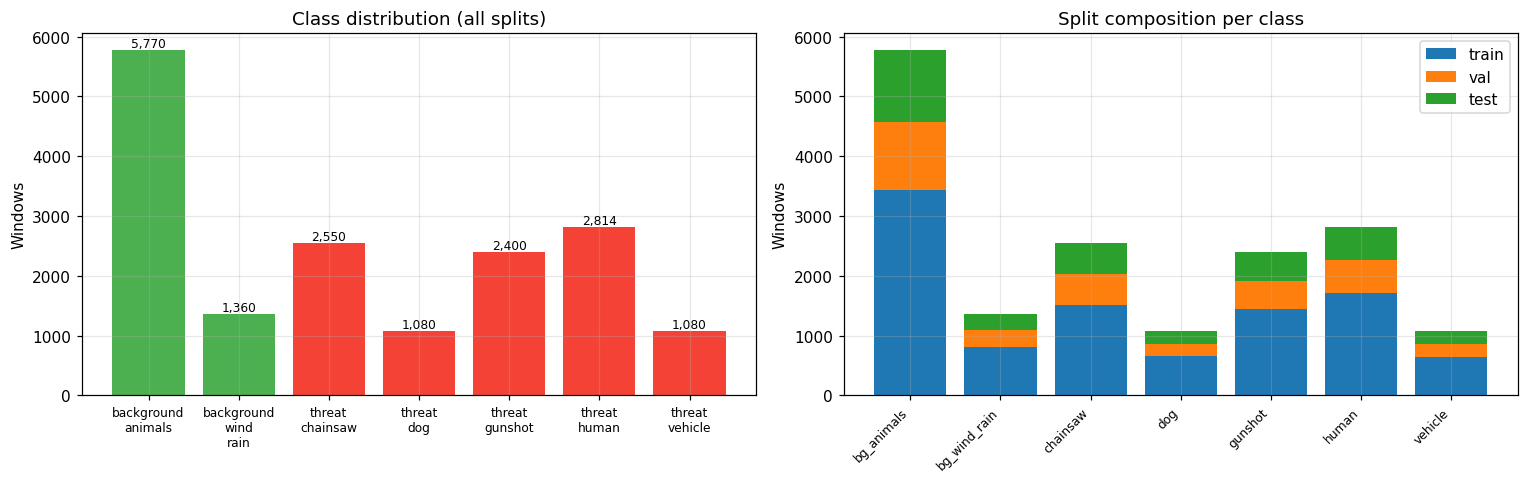

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Per-class totals
ax = axes[0]
ax.bar(range(len(CLASSES)), dist["total"], color=COLORS)
ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels([c.replace("_","\n") for c in CLASSES], fontsize=8)
ax.set_ylabel("Windows"); ax.set_title("Class distribution (all splits)")
for i,v in enumerate(dist["total"]): ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=8)

# Stacked train/val/test
ax = axes[1]
bottom = np.zeros(len(CLASSES))
for split, col in zip(["train","val","test"], ["#1f77b4","#ff7f0e","#2ca02c"]):
    ax.bar(range(len(CLASSES)), dist[split], bottom=bottom, label=split, color=col)
    bottom += dist[split].values
ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels([SHORT[c] for c in CLASSES], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Windows"); ax.set_title("Split composition per class"); ax.legend()

plt.tight_layout(); plt.show()


### Example log-mel spectrogram per class

One real test clip per class — the `(128, 301)` dB-scaled input the models actually see.


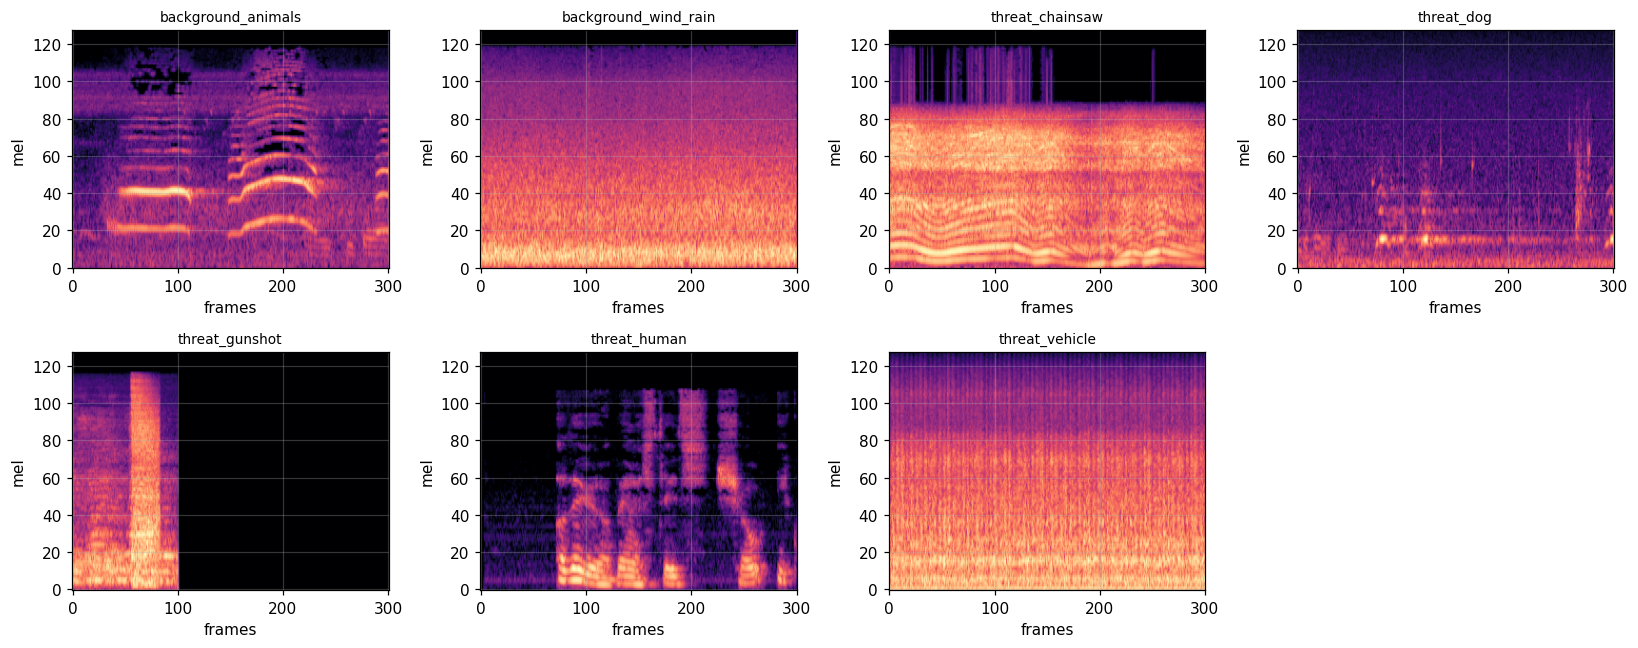

In [4]:
# Pull one example mel per class from the test shards
examples = {}
for s in sorted((REPO/"data/processed/mel/test").glob("*.npz")):
    d = np.load(s); X, y = d["X"], d["y"]
    for i, lab in enumerate(y):
        examples.setdefault(int(lab), X[i].astype(np.float32))
    if len(examples) == len(CLASSES): break

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for c in range(len(CLASSES)):
    ax = axes[c//4][c%4]
    ax.imshow(examples[c], origin="lower", aspect="auto", cmap="magma")
    ax.set_title(CLASSES[c], fontsize=9); ax.set_xlabel("frames"); ax.set_ylabel("mel")
axes[1][3].axis("off")
plt.tight_layout(); plt.show()


## 2. Model Performance — all five models

Four ML paradigms: supervised CNN, few-shot ProtoNet, frozen-transfer W2V2-L2,
unsupervised Conv-AE, and classical OC-SVM. The first three are 7-class classifiers;
Conv-AE and OC-SVM are binary anomaly detectors (threat vs. background).


In [5]:
def load_results(name):
    return json.loads((REPO/f"models/{name}/results.json").read_text())

R = {m: load_results(m) for m in ["custom_cnn","protonet","w2v2_l2","conv_ae","oc_svm"]}

PARADIGM = {"custom_cnn":"Supervised CNN","protonet":"Few-shot ProtoNet",
            "w2v2_l2":"Transfer W2V2-L2","conv_ae":"Unsup. Conv-AE","oc_svm":"Classical OC-SVM"}

rows = []
for m, r in R.items():
    rows.append({
        "model": PARADIGM[m],
        "test_acc":  r.get("test_acc"),
        "macro_f1":  r.get("test_macro_f1"),
        "AUC":       r.get("macro_auc", r.get("binary_auc")),
        "type": "7-class" if "test_macro_f1" in r else "binary anomaly",
    })
summary = pd.DataFrame(rows).set_index("model")
display(summary.style.format({"test_acc":"{:.4f}","macro_f1":"{:.4f}","AUC":"{:.4f}"}, na_rep="—"))


,test_acc,macro_f1,AUC,type
model,,,,
Supervised CNN,0.9264,0.9166,—,7-class
Few-shot ProtoNet,0.9311,0.9205,0.9938,7-class
Transfer W2V2-L2,0.9297,0.9210,0.9911,7-class
Unsup. Conv-AE,—,—,0.6033,binary anomaly
Classical OC-SVM,—,—,0.7790,binary anomaly


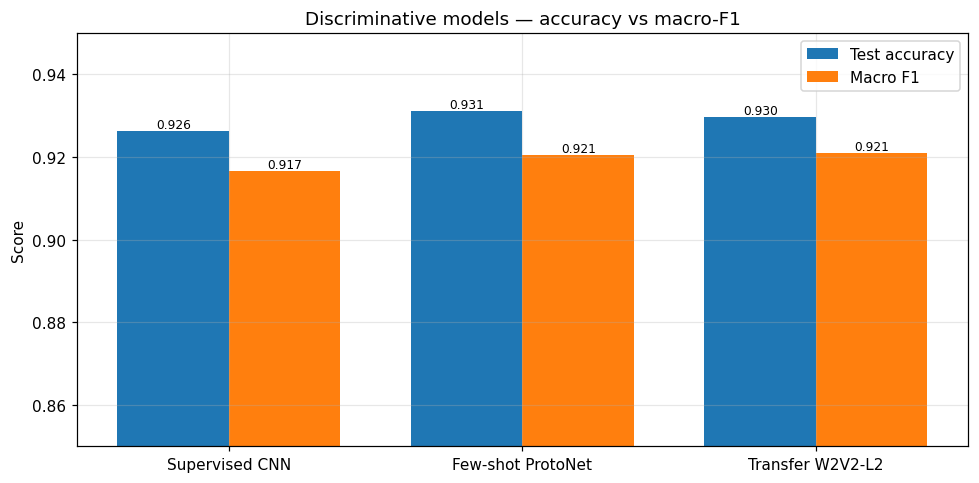

In [6]:
# Headline metrics for the 3 discriminative (7-class) models
disc = ["custom_cnn","protonet","w2v2_l2"]
labels = [PARADIGM[m] for m in disc]
acc = [R[m]["test_acc"] for m in disc]
f1  = [R[m]["test_macro_f1"] for m in disc]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(disc)); w = 0.38
ax.bar(x-w/2, acc, w, label="Test accuracy", color="#1f77b4")
ax.bar(x+w/2, f1,  w, label="Macro F1",      color="#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.85, 0.95); ax.set_ylabel("Score"); ax.set_title("Discriminative models — accuracy vs macro-F1")
for i,(a,f) in enumerate(zip(acc,f1)):
    ax.text(i-w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i+w/2, f, f"{f:.3f}", ha="center", va="bottom", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()


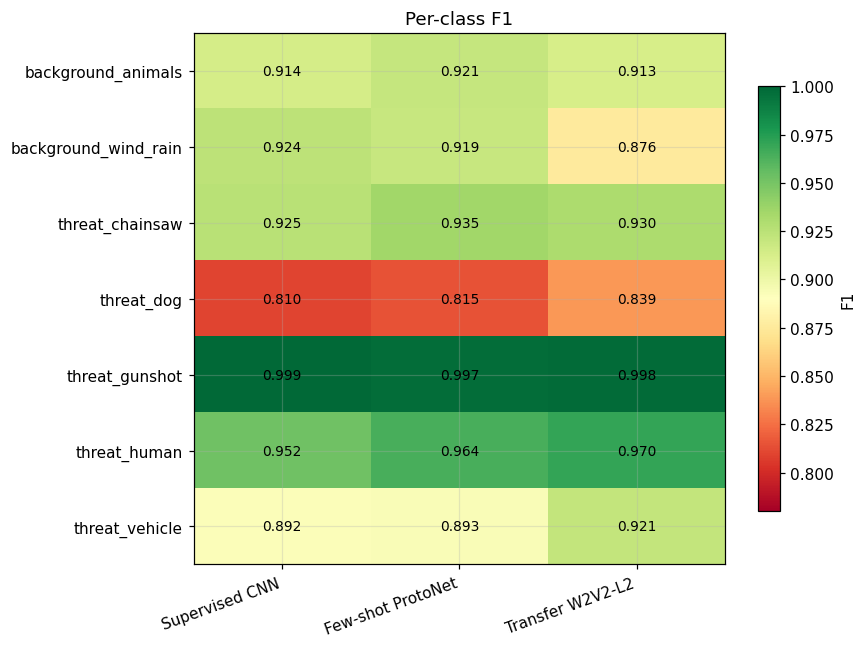

,Supervised CNN,Few-shot ProtoNet,Transfer W2V2-L2
background_animals,0.9140,0.9205,0.9131
background_wind_rain,0.9236,0.9194,0.8757
threat_chainsaw,0.9254,0.9348,0.9304
threat_dog,0.8098,0.8148,0.8386
threat_gunshot,0.9990,0.9969,0.9979
threat_human,0.9521,0.9641,0.9702
threat_vehicle,0.8922,0.8932,0.9210


In [7]:
# Per-class F1 heatmap (CNN / ProtoNet / W2V2)
pcf = {}
for m in disc:
    d = R[m]["per_class_f1"]
    pcf[PARADIGM[m]] = [d.get(c, d.get(SHORT[c])) for c in CLASSES]
pcf = pd.DataFrame(pcf, index=CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pcf.values, cmap="RdYlGn", vmin=0.78, vmax=1.0, aspect="auto")
ax.set_xticks(range(pcf.shape[1])); ax.set_xticklabels(pcf.columns, rotation=20, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for i in range(pcf.shape[0]):
    for j in range(pcf.shape[1]):
        ax.text(j, i, f"{pcf.values[i,j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("Per-class F1"); fig.colorbar(im, ax=ax, shrink=0.8, label="F1")
plt.tight_layout(); plt.show()
display(pcf.style.format("{:.4f}"))


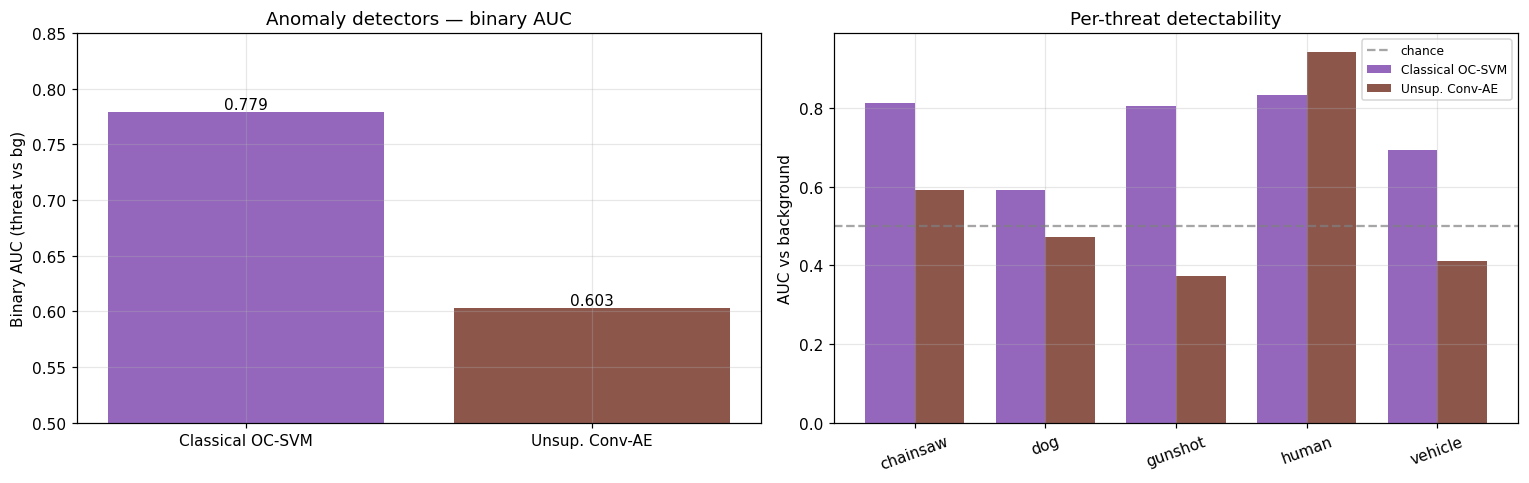

In [8]:
# Anomaly detectors — binary AUC + per-class threat detectability
anom = ["oc_svm","conv_ae"]
THREATS = [c for c in CLASSES if c.startswith("threat")]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
bauc = [R[m]["binary_auc"] for m in anom]
ax.bar([PARADIGM[m] for m in anom], bauc, color=["#9467bd","#8c564b"])
ax.set_ylim(0.5, 0.85); ax.set_ylabel("Binary AUC (threat vs bg)"); ax.set_title("Anomaly detectors — binary AUC")
for i,v in enumerate(bauc): ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")

ax = axes[1]
x = np.arange(len(THREATS)); w = 0.38
for k,(m,col) in enumerate(zip(anom, ["#9467bd","#8c564b"])):
    vals = [R[m]["per_class_auc"].get(t, np.nan) for t in THREATS]
    ax.bar(x + (k-0.5)*w, vals, w, label=PARADIGM[m], color=col)
ax.axhline(0.5, ls="--", c="gray", alpha=0.7, label="chance")
ax.set_xticks(x); ax.set_xticklabels([t.replace("threat_","") for t in THREATS], rotation=20)
ax.set_ylabel("AUC vs background"); ax.set_title("Per-threat detectability"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Takeaway.** The three discriminative models are statistically tied at the top
(macro-F1 ≈ 0.92), with **gunshot** — the highest-stakes class — detected near-perfectly by all.
The anomaly-detection paradigm is markedly weaker, though the classical **OC-SVM** clearly beats
the deep **Conv-AE** and, crucially, recovers gunshot detection that Conv-AE fails on.


## 3. Grad-CAM Explainability (deployed CNN)

Grad-CAM highlights the time-frequency regions that drove each prediction. Computed on the
trained PyTorch CNN over one real test clip per class — the heatmap (jet) is overlaid on the
mel spectrogram (magma). Red = most influential region.


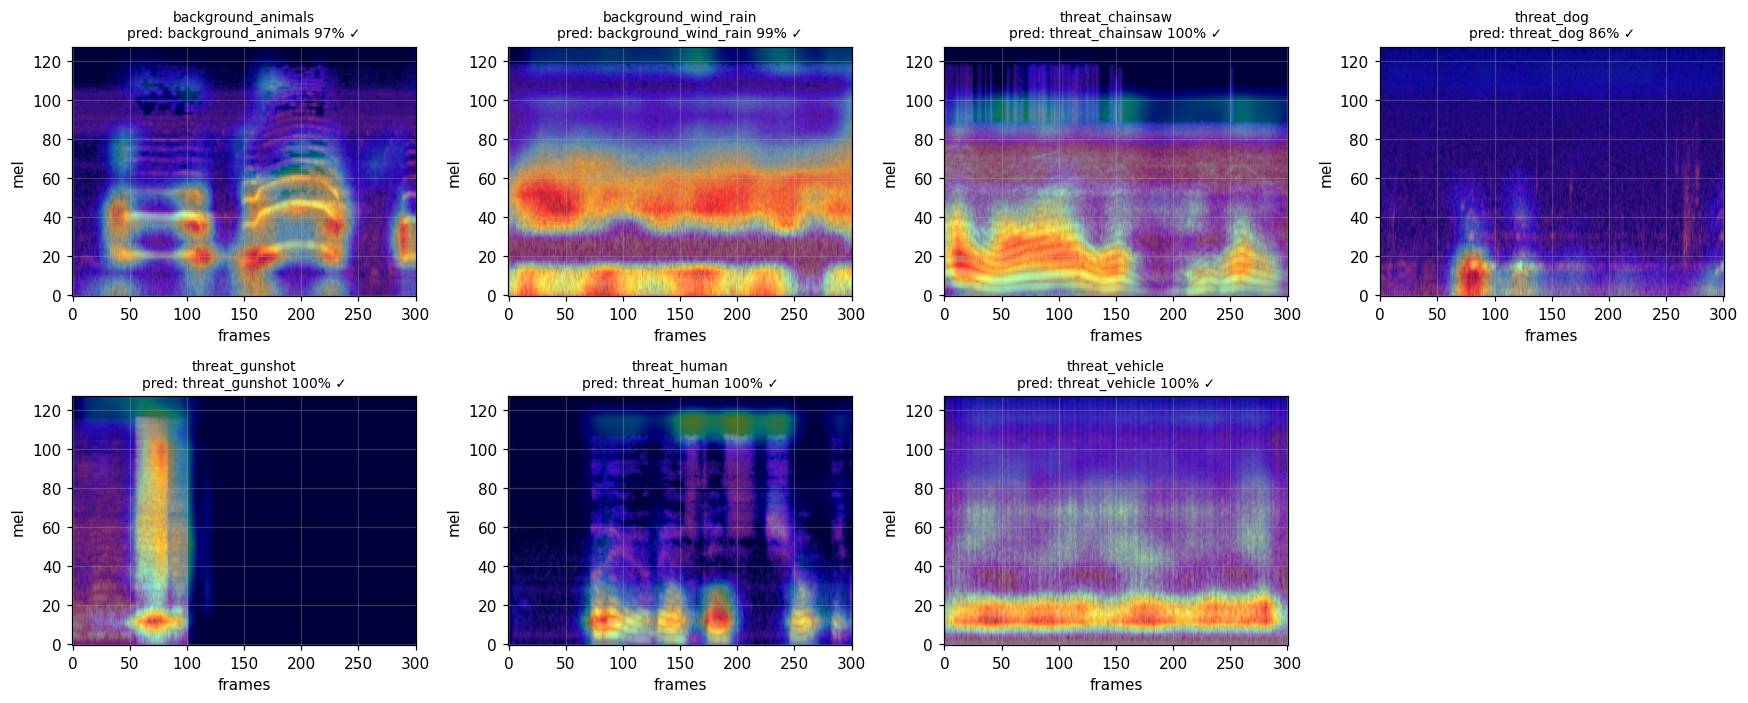

In [9]:
sys.path.insert(0, str(REPO/"dashboard"))
from gradcam import GradCAM, CLASS_NAMES

cam = GradCAM(REPO/"models/custom_cnn/best_model.pt")

fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for c in range(len(CLASSES)):
    mel = examples[c]
    heat, pred, probs = cam(mel)
    ax = axes[c//4][c%4]
    ax.imshow(mel,  origin="lower", aspect="auto", cmap="magma")
    ax.imshow(heat, origin="lower", aspect="auto", cmap="jet", alpha=0.45)
    ok = "✓" if pred == c else "✗"
    ax.set_title(f"{CLASSES[c]}\npred: {CLASS_NAMES[pred]} {probs[pred]:.0%} {ok}", fontsize=9)
    ax.set_xlabel("frames"); ax.set_ylabel("mel")
axes[1][3].axis("off")
plt.tight_layout(); plt.show()


**Interpretation.** The CNN focuses on physically meaningful regions — the broadband
transient for gunshots, the sustained mid-band for chainsaw/vehicle, and harmonic speech bands for
human — confirming the model attends to the right acoustic cues rather than spurious artefacts.
This Grad-CAM view is served live on the LAN dashboard (`dashboard/`) for each field detection.
